# Transformer on PLAsTiCC: using augmented lightcurves, raw datapoints

This notebook uses the `dlip_plasticc` package on top of `avocado`.

### Notebook parameters

In [1]:
# Notebook parameters

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# Training
TRAIN_DATASET_NAME = 'plasticc_augment_daniil'
CLASSIFIER_NAME = 'my_transformer'
SEQ_LEN = 350
NUM_EPOCHS = 60
BATCH_SIZE = 64
LR = 1e-4
NUM_FOLDS = 5
RANDOM_STATE = 42
VAL_FOLD = 0
WEIGHT_DECAY = 5e-2
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
MIN_LR = 1e-6
EARLY_STOPPING_PATIENCE = 8

# Transformer architecture
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 4
DIM_FEEDFORWARD = 512
DROPOUT = 0.3

# Prediction
TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS = 500

CHUNKS = range(21)

# Output location for per-chunk and combined predictions.
OUT_DIR = 'notebook_outputs/transformer_predictions'

# Confusion matrix display options
CONFUSION_NORMALIZE = 'true'  # one of: None, 'true', 'pred', 'all'
FIGSIZE_HISTORY = (8, 5)
FIGSIZE_CONFUSION = (10, 8)

### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import TransformerClassifier
from dlip_plasticc.pipelines.predict import predict_partial_from_dataset
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

### Paths

These are set by the `avocado_settings.json` file.

In [3]:
# Load config and push paths into avocado
cfg = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(cfg)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])

Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


### Determine class weights

In [4]:
# get class counts from training metadata
metadata = avocado.load('plasticc_augment_daniil', metadata_only=True).metadata
class_counts = metadata['class'].value_counts()

# dampened inverse frequency 
DAMPING = 0.5 # raise to power < 1 to soften the effect
inv_freq = 1.0 / class_counts
inv_freq = inv_freq ** DAMPING
inv_freq = inv_freq / inv_freq.mean()  # normalise so mean = 1

class_weights = inv_freq.to_dict()
print(class_weights)

{90: 0.3428638567577157, 16: 0.46790670714945, 42: 0.47502686939593874, 65: 0.49859290648245874, 15: 0.6557511927179571, 88: 0.7670256212687797, 62: 0.7830713376017605, 92: 0.8882289777209923, 95: 1.0911402443623275, 6: 1.1750549023222183, 67: 1.1985998858360851, 52: 1.2454436323165041, 64: 1.9042423353494153, 53: 2.507051530718397}


## 1. Train the transformer

This uses online sequence featurisation from raw observations in the training dataset.

In [ ]:
featurizer = PlasticcSequenceFeaturizer(seq_len=SEQ_LEN)

classifier = TransformerClassifier(
    name=CLASSIFIER_NAME,
    featurizer=featurizer,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    #class_weights=class_weights,
)

print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
train_dataset = avocado.load(TRAIN_DATASET_NAME)

print('Extracting sequence raw features...')
train_dataset.extract_raw_features(featurizer)

print(f"Training classifier '{CLASSIFIER_NAME}'...")
classifier.train(
    train_dataset,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")


Loading training dataset 'plasticc_augment_daniil'...
Extracting sequence raw features...


Object: 100%|██████████| 95914/95914 [01:11<00:00, 1333.78it/s]


Training classifier 'my_transformer'...


Epochs:   0%|          | 0/60 [00:00<?, ?it/s]/home6/s4339150/miniconda/envs/project/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Epochs:   2%|▏         | 1/60 [00:29<29:09, 29.66s/it]

Epoch 1 train_loss: 1.55664 val_loss: 1.53741 val_acc: 0.47065 lr: 1.000000e-04


...

Epoch 3 train_loss: 1.13773 val_loss: 1.34081 val_acc: 0.52070 lr: 1.000000e-04


Epochs:   7%|▋         | 4/60 [01:47<24:39, 26.43s/it]

Epoch 4 train_loss: 1.07733 val_loss: 1.22288 val_acc: 0.57998 lr: 1.000000e-04


Epochs:   8%|▊         | 5/60 [02:13<24:08, 26.33s/it]

Epoch 5 train_loss: 1.03274 val_loss: 1.31661 val_acc: 0.53315 lr: 1.000000e-04


In [5]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)


Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_transformer_seq.pkl


## 2. Plot training history

In [6]:
history = classifier.history.copy()
history.tail()

,epoch,train_loss,val_loss,val_acc,lr
35,36,0.640133,0.906110,0.697849,0.000006
36,37,0.638876,0.908407,0.697924,0.000003
37,38,0.636491,0.906142,0.700454,0.000003
38,39,0.635638,0.905676,0.699859,0.000003
39,40,0.637640,0.907418,0.699561,0.000002


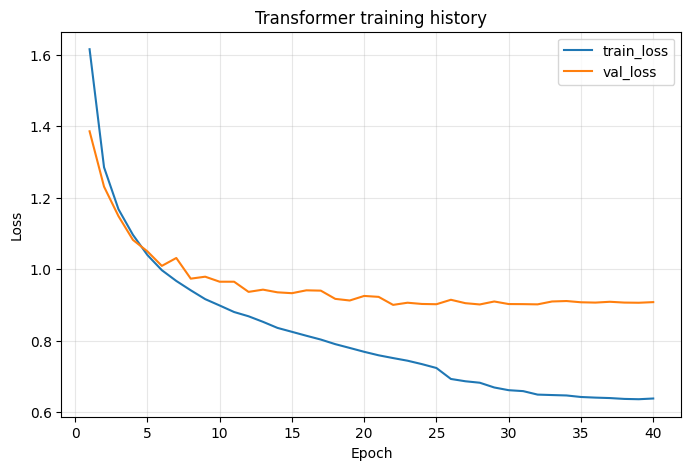

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['train_loss'], label='Training loss')
ax.plot(history['epoch'], history['val_loss'], label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Log-loss')
ax.set_title('Transformer training history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 3. Predict on test chunks

In [9]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

combined_predictions, processed_chunks = predict_partial_from_dataset(
    classifier=classifier,
    featurizer=featurizer,
    dataset_name=TEST_DATASET_NAME,
    total_chunks=TOTAL_CHUNKS,
    chunks=CHUNKS,
    out_dir=OUT_DIR,
    metadata_only=False,
    show_progress=True,
)

print('Processed chunks:', processed_chunks)
print('Combined prediction shape:', combined_predictions.shape)
combined_predictions.head()


Chunks: 100%|██████████| 21/21 [02:41<00:00,  7.70s/it]

Processed chunks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Combined prediction shape: (146701, 14)


,6,15,16,42,52,53,62,64,65,67,88,90,92,95
object_id,,,,,,,,,,,,,,
plasticc_000000013,0.000067,0.000063,1.086401e-07,0.310530,0.033147,4.033044e-09,0.055110,1.651084e-07,0.000003,0.003660,9.394647e-06,0.519096,2.407281e-09,0.078316
plasticc_000000014,0.000402,0.001196,5.972094e-06,0.287484,0.068214,8.359131e-08,0.047768,2.896990e-05,0.000406,0.022160,2.919384e-04,0.561754,6.560684e-07,0.010287
plasticc_000000017,0.000391,0.013790,1.682493e-03,0.228193,0.046879,4.425398e-07,0.062777,1.017502e-03,0.025111,0.020024,2.704794e-02,0.568078,2.132834e-05,0.004987
plasticc_000000023,0.001240,0.001345,3.800214e-06,0.144480,0.022459,9.046425e-08,0.139317,1.646760e-04,0.000335,0.116255,4.050045e-05,0.558039,1.526515e-07,0.016321
plasticc_000000034,0.000030,0.000100,2.943050e-08,0.017978,0.020749,2.197406e-10,0.003330,2.524539e-06,0.000019,0.004163,8.157907e-07,0.952234,1.316941e-09,0.001392


## 4. Score predictions with avocado flat-weighted logloss

This scores only on the overlapping labeled objects available in the metadata.

In [ ]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, combined_predictions)
print(f'Flat-weighted logloss: {flat_score:.5f}')
print(f'Objects scored:        {n_scored:,}')

Flat-weighted logloss: 1.34020
Objects scored:        146,085


## 5. Confusion matrix and classification report

In [ ]:
# Labels for plots

plot_labels = {
    6: 'Single micro-lens - 6',
    15: 'TDE - 15',
    16: 'Eclipsing Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_short = {
    6: 'Single $\mu$-lens - 6',
    15: 'TDE - 15',
    16: 'Eclip. Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_extra_short = {
    6: 'Single $\mu$-lens',
    15: 'TDE',
    16: 'Eclip. Binary',
    42: 'SNII',
    52: 'SNIax',
    53: 'Mira',
    62: 'SNIbc',
    64: 'Kilonova',
    65: 'M-dwarf',
    67: 'SNIa-91bg',
    88: 'AGN',
    90: 'SNIa',
    92: 'RR lyrae',
    95: 'SLSN-I',
    99: 'Unknown',
}

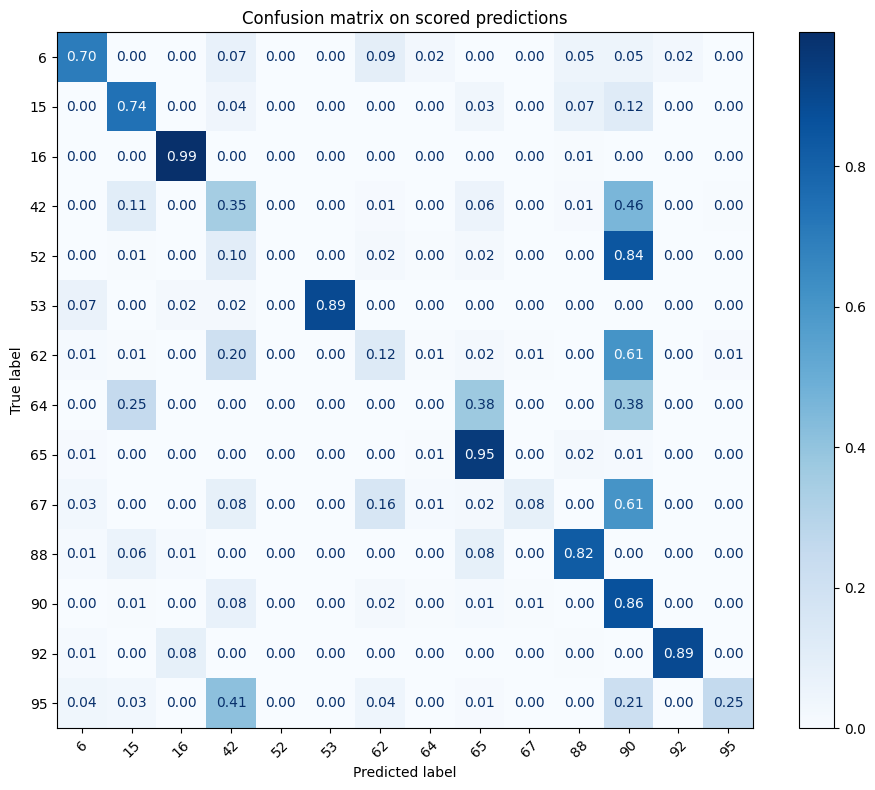

: 

In [ ]:
y_true, pred_aligned = align_truth_and_predictions(
    avocado_test.metadata,
    preds,
    known_classes_only=True,
    normalize=True,
)

y_pred = pred_aligned.idxmax(axis=1)
labels = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

# map numeric class ids to readable labels
display_labels = [plot_labels_short.get(l, str(l)) for l in labels]

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels,  # readable labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
    cmap=plt.cm.Blues,
    values_format=".2f",
)

ax.set_title("Confusion matrix on scored predictions")
plt.tight_layout()
plt.show()

In [22]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           6     0.0587    0.5349    0.1057        43
          15     0.0740    0.8267    0.1359       479
          16     0.9615    0.9644    0.9629      3233
          42     0.7608    0.5179    0.6163     48142
          52     0.3077    0.0014    0.0028      2864
          53     0.6250    0.9783    0.7627        46
          62     0.3481    0.1925    0.2479      7859
          64     0.0000    0.0000    0.0000         8
          65     0.6134    0.9557    0.7473      3095
          67     0.1978    0.2068    0.2022      1673
          88     0.9094    0.9116    0.9105      3743
          90     0.7077    0.8552    0.7745     66848
          92     0.9841    0.9673    0.9756      6781
          95     0.3566    0.4500    0.3979      1271

    accuracy                         0.6917    146085
   macro avg     0.4932    0.5973    0.4887    146085
weighted avg     0.7084    0.6917    0.6831    146085

